<a href="https://colab.research.google.com/github/Juanezm/ml-model-battery-levels-iot/blob/main/scenario_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### **Escenario 1**: Conjuntos de datos de entrenamiento y prueba separados  
#### En este primer escenario, el modelo se entrena utilizando el conjunto de datos 1, reservando el 20% de los datos para validación.
#### La prueba se realiza utilizando el conjunto de datos 0.
#### Este método evalúa la capacidad del modelo cuando es entrenado y probado en diferentes conjuntos de datos.

In [1]:
# Primero
#id_train = "270043001951343334363036"
#id_test = "46004e000251353337353037"

In [2]:
# Segundo
#id_train = "4e0031000251353337353037"
#id_test = "46004e000251353337353037"

In [3]:
# Tercero
id_train = "200034001951343334363036"
id_test = "46005a000351353337353037"

In [4]:
# Cuarto
#id_train = "380033001951343334363036"
#id_test = "46005a000351353337353037"

In [5]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from keras.models import Sequential
from keras.layers import LSTM, GRU, Dense, Bidirectional, TimeDistributed, Conv1D, Flatten, MaxPooling1D
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split

from IPython.display import clear_output
from IPython.display import HTML
#import imgkit

### Variables a definir

In [6]:
seq_length = 72 #120
forecast_steps = seq_length
future_steps = 1
intervalo = "15min"

In [7]:
quitar = ["soil_humidity"]
re_sample = "1H"
cut_train = 0
cut_test = 0

#### Función para normalizar los datos

In [8]:
def normalise_data(scaler_x, x, scaler_y, y):# Utiliza MinMaxScaler
    X_train = pd.DataFrame(scaler_x.fit_transform(x))
    y_train = pd.DataFrame(scaler_y.fit_transform(y.values.reshape(-1, 1)))
    return X_train, y_train

####  La función create_sequences toma dos conjuntos de datos, X e y, y un parámetro seq_length que define la longitud de cada secuencia de entrada que se va a crear. Su objetivo es estructurar los datos en secuencias de longitud fija, lo cual es muy útil en modelos que procesan secuencias, como los modelos de series temporales o redes neuronales recurrentes (RNNs).

#### El bucle for recorre los datos hasta len(X) - seq_length para garantizar que se pueden crear secuencias completas de longitud seq_length.
#### En cada iteración:
#### X[i:(i+seq_length)]: Extrae una secuencia de longitud seq_length de X, que va desde el índice i hasta i+seq_length (sin incluir i+seq_length). Esta secuencia se agrega a xs.
#### y[i+seq_length]: Obtiene el valor objetivo en el índice i + seq_length y lo agrega a ys. Esto representa el valor que queremos predecir después de observar la secuencia anterior.

In [9]:
def create_sequences(X, y, seq_length):
    xs = []
    ys = []

    for i in range(len(X)-seq_length):
        xs.append(X[i:(i+seq_length)])
        ys.append(y[i+seq_length])

    return np.array(xs), np.array(ys)

#### La clase PlotLearning es una callback personalizada de Keras que se usa para graficar las métricas de entrenamiento y validación durante el proceso de entrenamiento de un modelo. Hereda de Callback, que es una clase de Keras que permite ejecutar código específico en diferentes momentos del entrenamiento (como al inicio o al final de cada época).

#### - Metodo **on_train_begin**: Este método se ejecuta al inicio del entrenamiento. Inicializa listas vacías para almacenar las métricas de:
- Error absoluto medio (MAE) en el conjunto de entrenamiento (train_mean_absolute_error).
- Pérdida en el conjunto de entrenamiento (train_loss).
- Error absoluto medio (MAE) en el conjunto de validación (val_mean_absolute_error).
- Pérdida en el conjunto de validación (val_loss).

#### método **on_epoch_end**: Este método se ejecuta al final de cada época. Extrae las métricas del argumento logs, que contiene el valor de diferentes métricas calculadas al final de la época, y las agrega a las listas correspondientes:
- mean_absolute_error y loss: Son métricas del conjunto de entrenamiento.
- val_mean_absolute_error y val_loss: Son métricas del conjunto de validación.

#### clear_output(wait=True): Borra el contenido anterior para que el gráfico de métricas se actualice en cada época.
#### plt.figure(figsize=(12, 5)): Define el tamaño de la figura para que sea más amplia y fácil de leer.

#### plt.tight_layout(): Ajusta el espaciado para que las gráficas se acomoden bien en la figura.

In [10]:
class PlotLearning(Callback):
    """
    Callback to plot the metrics during training.
    """
    def on_train_begin(self, logs={}):
        self.train_mean_absolute_error = []
        self.train_loss = []
        self.val_mean_absolute_error = []
        self.val_loss = []

    def on_epoch_end(self, epoch, logs={}):
        self.train_mean_absolute_error.append(logs.get('mean_absolute_error'))
        self.train_loss.append(logs.get('loss'))
        self.val_mean_absolute_error.append(logs.get('val_mean_absolute_error'))
        self.val_loss.append(logs.get('val_loss'))

        clear_output(wait=True)
        plt.figure(figsize=(12, 5))

        # Graficar precisión MAE
        plt.subplot(1, 2, 1)
        plt.plot(range(1, epoch + 2), self.train_mean_absolute_error, 'o--', label='Training MAE')
        plt.plot(range(1, epoch + 2), self.val_mean_absolute_error, 'o--', label='Validation MAE')
        plt.xlabel('# epochs')
        plt.ylabel('MAE')
        plt.legend()
        plt.grid()

        # Graficar pérdida MSE
        plt.subplot(1, 2, 2)
        plt.plot(range(1, epoch + 2), self.train_loss, 'o--', label='Training MSE')
        plt.plot(range(1, epoch + 2), self.val_loss, 'o--', label='Validation MSE')
        plt.xlabel('# epochs')
        plt.ylabel('MSE')
        plt.legend()
        plt.grid()

        plt.tight_layout()
        plt.show()

### Parámetros de entrada:

#### test: DataFrame que contiene los datos de prueba con columnas como "Rain meter", "Soil moisture", "Battery" y "date".
#### seq_length: Longitud de la secuencia usada para formar las entradas al modelo.
#### forecast_steps: Número total de pasos a predecir.
#### future_steps: Número de pasos para actualizar la predicción con los datos históricos.
#### model: Modelo predictivo usado para el pronóstico.
#### scaler_x y scaler_y: Escaladores para normalizar las características y el objetivo, respectivamente.

### Inicialización de los datos históricos y del pronóstico:

#### historical_data: Primeros seq_length+1 datos para usar como secuencia inicial.
#### forecast_data: Conjunto de datos sobre el que se va a realizar el pronóstico.
#### weather_forecast: DataFrame de forecast_data sin la columna "Battery", que será reemplazada por predicciones.

### Bucle de pronóstico:

#### El bucle recorre forecast_steps, y en cada iteración:
- Normaliza los datos históricos usando normalise_data.
- Crea secuencias con create_sequences para proporcionar datos secuenciales al modelo.
- Realiza la predicción del siguiente nivel de batería usando el modelo, luego inversa la normalización de la predicción para obtener el valor real de batería.
- Agrega la predicción al pronóstico en weather_forecast, reemplazando valores NaN con la predicción.
- Actualiza los datos históricos concatenando los datos más recientes del pronóstico en updated_historical_data.

In [11]:
def forecast_battery_consumption(test, seq_length, forecast_steps, future_steps, model, scaler_x, scaler_y):
    """
    This function is used to forecast battery consumption based on historical data.

    Parameters:
    test (pd.DataFrame): DataFrame that contains test data including 'Rain meter', 'Soil moisture', 'Battery' and 'date' columns.
    seq_length (int): Sequence length used for creating input sequences for the model.
    forecast_steps (int): Number of steps ahead to forecast.
    future_steps (int): Number of steps to shift for updating historical data.
    model (model): model used for prediction.
    scaler_x (scaler): Scaler used for scaling the features.
    scaler_y (scaler): Scaler used for scaling the target.

    Returns:
    matplotlib.pyplot: Plot of actual vs forecasted battery consumption.
    """

    # Inicialización de las variables
    # Los 120 primeros valores del dataframe test_dataset con 9 var, fecha y battery como columnas de variables
    historical_data = test[:seq_length+1]
    # Los siguientes 120 valores del dataframe test_dataset, con las 9 variables igual, sobre el que hacemos la predicción
    forecast_data = test[seq_length:seq_length+forecast_steps]
    # Quitamos battery pero no fechas
    weather_forecast = forecast_data.drop(columns=['battery']) # Eliminamos la columna battery que se reemplaza por las predicciones
    # Insertamos una columna battery llena de Nan
    weather_forecast['battery'] = np.nan
    # Inicialmente de 0 hasta 120, son lo que se usan para las predicciones
    updated_historical_data = historical_data

    for steps in range(0, forecast_steps, future_steps): # desde 0 hasta 119 en pasos de 0 --> 119 pasos

        # normalise historical_data
        # update_historical_data tiene la última previsión incorporada para seguir haciendo predicciones
        X_hist, y_hist = normalise_data(
                                        scaler_x,
                                        updated_historical_data.drop(columns=['fecha']), # Va todo incluida la columna de battery
                                        #updated_historical_data.drop(columns=['fecha', "battery"]),
                                        scaler_y,
                                        updated_historical_data['battery'])

        # create sequences out of historical_data
        X_hist_seq, y_hist_seq = create_sequences(X_hist.values, y_hist.values, seq_length)

        # predict next battery level
        # next_battery_pred = y_pred
        next_battery_pred = model.predict(X_hist_seq)
        #evaluar = model.evaluate(X_hist_seq, y_hist_seq)
        clear_output(wait=True) # limpiar la salida de la celda actual, permitiendo actualizar la información mostrada en lugar de acumularla.


        # inverse normalisation of predicted battery level
        next_battery_pred_inv = scaler_y.inverse_transform(next_battery_pred)[0][0]

        # Add predicted value to weather forecast
        # Las predicciones están en weather forecast
        weather_forecast.loc[weather_forecast.index[steps:steps+future_steps], 'battery'] = next_battery_pred_inv

        # Update the historical data with the forecasted
        updated_historical_data = pd.concat([updated_historical_data[future_steps:], weather_forecast[steps:steps+future_steps]], ignore_index=True)


    # Plot actual vs predicted with dates
    plt.figure(figsize=(20, 6))

    plt.plot(pd.to_datetime(historical_data['fecha']), historical_data['battery'], label='Historic')
    plt.plot(pd.to_datetime(weather_forecast['fecha']), weather_forecast['battery'], label='Forecast', marker=".")
    plt.plot(pd.to_datetime(forecast_data['fecha']), forecast_data['battery'], label='Real', marker=".")
    plt.title('Actual vs Forecasted Battery Consumption')
    plt.xlabel('Time')
    plt.ylabel('Battery Consumption')
    plt.legend()
    plt.grid()
    plt.show()

    print('RMSE: ', root_mean_squared_error(forecast_data['battery'], weather_forecast['battery']))
    print('MSE:  ', mean_squared_error(forecast_data['battery'], weather_forecast['battery']))
    print('MAE:  ', mean_absolute_error(forecast_data['battery'], weather_forecast['battery']))

    return historical_data, weather_forecast, forecast_data, updated_historical_data

In [12]:
def compare_model_performance(test, seq_length, future_steps, models, scaler_x, scaler_y):
    """
    This function is used to compare the performance of multiple models in terms of their ability to predict battery
    consumption based on historical data. It returns a list of dictionaries, each containing the minimum, maximum, mean,
    and standard deviation of the Mean Absolute Error (MAE) for each model.

    Parameters:
    test (pd.DataFrame): DataFrame that contains test data including 'Rain meter', 'Soil moisture', 'Battery' and 'date' columns.
    seq_length (int): Sequence length used for creating input sequences for the model.
    future_steps (int): Number of steps to shift for updating historical data.
    models (dict): Dictionary of models used for prediction, with model names as keys and models as values.
    scaler_x (scaler): Scaler used for scaling the features.
    scaler_y (scaler): Scaler used for scaling the target.

    Returns:
    list: A list of dictionaries. Each dictionary contains the model name as the key and the 'min', 'max', 'mean' and 'std' of
    the Mean Absolute Error (MAE) for the corresponding model as values.
    """

    num_intervals = len(test) // seq_length + 1 # 3791 / 121 = 31
    metrics_list = {model_name: {'mae': [], 'fecha': [], 'stats': {}} for model_name, model in models}

    forecast_data_all = pd.DataFrame()

    # Para cada modelo hacemos el proceso
    for model_name, model in models:
        for i in range(num_intervals):
            # Recorremos todas las posibles secuencias de 120 datos, hasta el fin del dataset
            historical_data = test[i*seq_length:(i+1)*seq_length+1]
            # Último datos de cada secuencia de 120, sobre el cual realizamos la predicción
            forecast_data = test[(i+1)*seq_length:((i+1)*seq_length)+future_steps]
            # Quitamos batería
            weather_forecast = forecast_data.drop(columns=['battery'])
            # Rellenamos batería con Nan
            weather_forecast['battery'] = np.nan
            updated_historical_data = historical_data

            # Hacemos las predicciones igual que antes
            for steps in range(future_steps):
                if steps < len(weather_forecast):

                    # normalise historical_data
                    X_hist, y_hist = normalise_data(scaler_x,
                                                    updated_historical_data.drop(columns=['fecha']),
                                                    scaler_y,
                                                    updated_historical_data['battery'])
                    # create sequences out of historical_data
                    X_hist_seq, y_hist_seq = create_sequences(X_hist.values, y_hist.values, seq_length)

                    # predict next battery level
                    next_battery_pred = model.predict(X_hist_seq, verbose = 0)

                    # inverse normalisation of predicted battery level
                    next_battery_pred_inv = scaler_y.inverse_transform(next_battery_pred)[0][0]

                    # Add predicted value to weather forecast
                    weather_forecast.loc[weather_forecast.index[steps:steps+future_steps], 'battery'] = next_battery_pred_inv

                    # Update the historical data with the forecasted
                    updated_historical_data = pd.concat([updated_historical_data[1:], weather_forecast.iloc[[steps]]], ignore_index=True)


            clear_output(wait=True)
            print(f'{i}/{num_intervals} intervals ===>  {steps}/{future_steps} steps')

            if not forecast_data.empty and not weather_forecast['battery'].isnull().all():
                 # Save metrics to list
                metrics_list[model_name]['mae'].append(mean_absolute_error(forecast_data['battery'], weather_forecast['battery']))
                metrics_list[model_name]['fecha'].append(pd.to_datetime(updated_historical_data['fecha'])[0])


    plt.figure(figsize=(20, 6))

    for model_name, metrics in metrics_list.items():
        plt.plot(metrics['fecha'], metrics['mae'], label=model_name)
        metrics['stats'] = {'min': np.min(metrics['mae']), 'max': np.max(metrics['mae']), 'mean': np.mean(metrics['mae']), 'std': np.std(metrics['mae'])}

    plt.title('MAE over Time intervals')
    plt.xlabel('Interval')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid()
    plt.show()

    return [{model_name: metrics['stats']} for model_name, metrics in metrics_list.items()]

In [13]:
def df_to_image(df, filename):
    """
    Convert a pandas DataFrame into a styled PNG image, maintaining the order of the DataFrame as it is passed.

    Args:
      df (pandas.DataFrame): The DataFrame to convert.
      filename (str): The base name of the files to create. The HTML file will be named
          '{filename}.html' and the image file will be named '{filename}.png'.
    """

    sampled_df = df  # Si hay 10 o menos filas, mostrar todo el DataFrame

    # Redondear y estilizar el DataFrame
    styled = sampled_df.style.format(precision=2).set_table_styles(
        [dict(selector="tr:nth-of-type(odd) td", props=[("background", "#eee")]),
         dict(selector="tr:nth-of-type(even) td", props=[("background", "white")])])

    # Guardar como HTML y luego convertir a PNG
    html_file = f'{filename}.html'
    styled.to_html(html_file)
    imgkit.from_file(html_file, f'{filename}.png')
    os.remove(html_file)


### Cargamos el conjunto de datos según lo definido al principio

In [14]:
# Load data
sensor_ids = [
    "200034001951343334363036",
    "270043001951343334363036",
    "380033001951343334363036",
    "46004e000251353337353037",
    "46005a000351353337353037",
    "4e0022000251353337353037",
    "4e0031000251353337353037",
]

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [39]:
#completos_dir = "../src/datos"
#data_origen = "../src/data_download"
completos_dir = "/content/drive/My Drive/TFM/datos"

In [40]:
sensors_data_clean = {id: pd.read_csv(f"{completos_dir}/{id}_limpios_{intervalo}.csv", index_col=0, parse_dates=True) for id in sensor_ids}

In [41]:
train_dataset = sensors_data_clean[id_train][cut_train:]
test_dataset = sensors_data_clean[id_test][cut_test:]

In [42]:
print('Number of trainning sets: ', len(train_dataset))
print('Number of testing sets: ', len(test_dataset))

Number of trainning sets:  15714
Number of testing sets:  3834


In [43]:
train_dataset.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 15714 entries, 2018-04-02 00:00:00 to 2018-09-14 00:00:00
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   temperature    15714 non-null  float64
 1   pressure       15714 non-null  float64
 2   battery        15714 non-null  float64
 3   air_humidity   15714 non-null  float64
 4   soil_humidity  15714 non-null  float64
 5   wind_speed     15714 non-null  float64
 6   irradiancia    15714 non-null  float64
 7   minutos_dia    15714 non-null  int64  
dtypes: float64(7), int64(1)
memory usage: 1.1 MB


In [44]:
test_dataset.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3834 entries, 2018-08-24 00:00:00 to 2018-10-03 00:00:00
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   temperature    3834 non-null   float64
 1   pressure       3834 non-null   float64
 2   battery        3834 non-null   float64
 3   air_humidity   3834 non-null   float64
 4   soil_humidity  3834 non-null   float64
 5   wind_speed     3834 non-null   float64
 6   irradiancia    3834 non-null   float64
 7   minutos_dia    3834 non-null   int64  
dtypes: float64(7), int64(1)
memory usage: 269.6 KB


In [45]:
train_dataset.head()

,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
fecha,,,,,,,,
2018-04-02 00:00:00,13.56,1004.63,76.02,57.87,20.03,0.00,0.0,765
2018-04-02 00:15:00,13.33,1004.68,75.37,58.06,19.42,2.08,0.0,765
2018-04-02 00:45:00,13.48,1004.14,74.38,57.51,19.32,2.08,0.0,765
2018-04-02 01:00:00,13.10,1004.13,74.05,58.22,19.13,0.00,0.0,765
2018-04-02 01:15:00,12.84,1003.96,73.56,59.37,19.17,0.00,0.0,765


In [46]:
test_dataset.head()

,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
fecha,,,,,,,,
2018-08-24 00:00:00,22.46,986.00,70.94,60.43,69.66,2.41,0.0,807
2018-08-24 00:15:00,22.22,986.00,70.61,59.96,69.33,2.41,0.0,807
2018-08-24 00:30:00,21.84,986.14,70.28,60.01,69.33,0.00,0.0,807
2018-08-24 00:45:00,21.69,986.01,70.12,60.60,69.37,0.00,0.0,807
2018-08-24 01:00:00,21.29,986.32,69.62,60.81,69.58,0.00,0.0,807


#### Alineación de puntos de datos según marcas de tiempo

In [47]:
# Resample the DataFrame to 1-hour intervals, taking the mean of each interval
train_dataset = train_dataset.resample(re_sample).mean().ffill()
test_dataset = test_dataset.resample(re_sample).mean().ffill()

<ipython-input-47-35115b5696bd>:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  train_dataset = train_dataset.resample(re_sample).mean().ffill()
<ipython-input-47-35115b5696bd>:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  test_dataset = test_dataset.resample(re_sample).mean().ffill()


In [48]:
train_dataset.sample(5)

,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
fecha,,,,,,,,
2018-05-10 06:00:00,17.8150,1000.8325,55.0300,78.5075,22.6825,0.5200,153.36,857.0
2018-07-28 22:00:00,27.1775,1003.1400,77.2400,78.4350,14.1125,2.6000,0.00,867.0
2018-05-28 04:00:00,18.2650,1001.6125,61.8650,79.8900,23.4725,2.5975,0.00,888.0
2018-08-18 00:00:00,23.5675,1008.8550,71.5100,73.3650,13.8375,3.6400,0.00,822.0
2018-05-11 15:00:00,30.0725,1005.7875,82.2525,43.1750,29.6175,6.2325,493.78,859.0


In [49]:
test_dataset.sample(5)

,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
fecha,,,,,,,,
2018-09-04 17:00:00,36.4975,981.8050,79.4400,52.0300,36.5425,6.0325,80.05,780.0
2018-09-11 19:00:00,24.7825,992.9250,69.0475,71.8500,65.6650,1.2050,0.00,762.0
2018-09-23 00:00:00,21.2875,992.5100,65.2775,79.4600,47.1125,0.6025,0.00,730.0
2018-09-25 05:00:00,22.3525,992.7925,49.4325,64.6750,56.2425,1.2050,0.00,725.0
2018-09-13 23:00:00,21.2275,988.9200,65.2050,79.3025,24.0575,1.2050,0.00,756.0


In [50]:
# Reset the index to make 'date' a column again
train_dataset.reset_index(inplace=True)
test_dataset.reset_index(inplace=True)

In [51]:
train_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
0,2018-04-02 00:00:00,13.456667,1004.483333,75.256667,57.813333,19.5900,1.386667,0.0,765.0
1,2018-04-02 01:00:00,12.680000,1003.887500,73.480000,58.852500,19.2450,0.000000,0.0,765.0
2,2018-04-02 02:00:00,11.747500,1003.202500,72.250000,58.555000,19.8775,1.040000,0.0,765.0
3,2018-04-02 03:00:00,11.962500,1002.612500,71.182500,61.107500,20.6975,0.520000,0.0,765.0
4,2018-04-02 04:00:00,11.855000,1002.335000,70.200000,64.217500,19.5800,1.040000,0.0,765.0


In [52]:
test_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia
0,2018-08-24 00:00:00,22.0525,986.0375,70.4875,60.2500,69.4225,1.2050,0.0,807.0
1,2018-08-24 01:00:00,21.3825,986.2075,69.2125,61.7975,69.4900,1.2050,0.0,807.0
2,2018-08-24 02:00:00,24.1225,985.9675,67.7700,61.9850,69.7450,4.2200,0.0,807.0
3,2018-08-24 03:00:00,25.5925,985.7325,66.1450,60.5050,69.7275,5.4275,0.0,807.0
4,2018-08-24 04:00:00,24.4625,985.6400,64.2275,61.4950,68.8950,1.8075,0.0,807.0


In [53]:
# Extract the hour from the 'date' column
train_dataset["hora"] = train_dataset["fecha"].dt.hour
test_dataset["hora"]  = test_dataset["fecha"].dt.hour

In [54]:
train_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia,hora
0,2018-04-02 00:00:00,13.456667,1004.483333,75.256667,57.813333,19.5900,1.386667,0.0,765.0,0
1,2018-04-02 01:00:00,12.680000,1003.887500,73.480000,58.852500,19.2450,0.000000,0.0,765.0,1
2,2018-04-02 02:00:00,11.747500,1003.202500,72.250000,58.555000,19.8775,1.040000,0.0,765.0,2
3,2018-04-02 03:00:00,11.962500,1002.612500,71.182500,61.107500,20.6975,0.520000,0.0,765.0,3
4,2018-04-02 04:00:00,11.855000,1002.335000,70.200000,64.217500,19.5800,1.040000,0.0,765.0,4


In [55]:
test_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,soil_humidity,wind_speed,irradiancia,minutos_dia,hora
0,2018-08-24 00:00:00,22.0525,986.0375,70.4875,60.2500,69.4225,1.2050,0.0,807.0,0
1,2018-08-24 01:00:00,21.3825,986.2075,69.2125,61.7975,69.4900,1.2050,0.0,807.0,1
2,2018-08-24 02:00:00,24.1225,985.9675,67.7700,61.9850,69.7450,4.2200,0.0,807.0,2
3,2018-08-24 03:00:00,25.5925,985.7325,66.1450,60.5050,69.7275,5.4275,0.0,807.0,3
4,2018-08-24 04:00:00,24.4625,985.6400,64.2275,61.4950,68.8950,1.8075,0.0,807.0,4


In [56]:
# Drop variables not available from Open Weather API forecast
train_dataset = train_dataset.drop(columns=quitar)
test_dataset = test_dataset.drop(columns=quitar)

In [57]:
train_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
0,2018-04-02 00:00:00,13.456667,1004.483333,75.256667,57.813333,1.386667,0.0,765.0,0
1,2018-04-02 01:00:00,12.680000,1003.887500,73.480000,58.852500,0.000000,0.0,765.0,1
2,2018-04-02 02:00:00,11.747500,1003.202500,72.250000,58.555000,1.040000,0.0,765.0,2
3,2018-04-02 03:00:00,11.962500,1002.612500,71.182500,61.107500,0.520000,0.0,765.0,3
4,2018-04-02 04:00:00,11.855000,1002.335000,70.200000,64.217500,1.040000,0.0,765.0,4


In [58]:
test_dataset.head()

,fecha,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
0,2018-08-24 00:00:00,22.0525,986.0375,70.4875,60.2500,1.2050,0.0,807.0,0
1,2018-08-24 01:00:00,21.3825,986.2075,69.2125,61.7975,1.2050,0.0,807.0,1
2,2018-08-24 02:00:00,24.1225,985.9675,67.7700,61.9850,4.2200,0.0,807.0,2
3,2018-08-24 03:00:00,25.5925,985.7325,66.1450,60.5050,5.4275,0.0,807.0,3
4,2018-08-24 04:00:00,24.4625,985.6400,64.2275,61.4950,1.8075,0.0,807.0,4


In [59]:
#X_trains = []
#y_trains = []
#X_vals = []
#y_vals = []

In [60]:
# Normalise Data
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

In [61]:
# Split dataset in train and validation
X_train, X_val, y_train, y_val = train_test_split(
      train_dataset.drop(columns=["fecha"]),
      train_dataset["battery"],
      test_size=0.2,
      shuffle=False
  )

In [62]:
X_train.head(12)

,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
0,13.456667,1004.483333,75.256667,57.813333,1.386667,0.00,765.0,0
1,12.680000,1003.887500,73.480000,58.852500,0.000000,0.00,765.0,1
2,11.747500,1003.202500,72.250000,58.555000,1.040000,0.00,765.0,2
3,11.962500,1002.612500,71.182500,61.107500,0.520000,0.00,765.0,3
4,11.855000,1002.335000,70.200000,64.217500,1.040000,0.00,765.0,4
5,11.882500,1001.755000,69.212500,62.810000,1.040000,0.00,765.0,5
6,10.905000,1001.145000,67.882500,63.180000,1.560000,42.60,765.0,6
7,10.732500,1000.985000,66.397500,62.742500,1.040000,155.38,765.0,7
8,12.112500,1000.930000,64.697500,60.677500,1.040000,284.34,765.0,8
9,14.037500,1000.992500,64.012500,52.920000,1.560000,406.05,765.0,9


In [63]:
#df_img = X_train.head(12)
#df_to_image(df_img, "df_24horas")

In [ ]:
X_val.head()

,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
3168,27.0700,1009.370,69.0500,79.19,0.52,0.0,836.0,0
3169,26.7425,1008.925,66.9400,78.95,0.52,0.0,836.0,1
3170,26.2950,1008.195,64.9175,78.70,1.56,0.0,836.0,2
3171,25.9500,1007.725,62.6750,78.46,0.00,0.0,836.0,3
3172,25.5425,1007.285,59.3175,78.22,2.08,0.0,836.0,4


In [64]:
y_train.head(3)

,battery
0,75.256667
1,73.480000
2,72.250000


In [65]:
y_val.head(3)

,battery
3168,69.0500
3169,66.9400
3170,64.9175


In [66]:
# Normalise train and validation datasets
X_train_norm, y_train_norm = normalise_data(scaler_x, X_train, scaler_y, y_train)
X_val_norm, y_val_norm = normalise_data(scaler_x, X_val, scaler_y, y_val)

In [67]:
X_train_norm.head()

,0,1,2,3,4,5,6,7
0,0.122983,0.692589,0.770880,0.630312,0.133462,0.0,0.0,0.000000
1,0.101800,0.675299,0.748231,0.647668,0.000000,0.0,0.0,0.043478
2,0.076367,0.655423,0.732551,0.642699,0.100096,0.0,0.0,0.086957
3,0.082231,0.638303,0.718943,0.685331,0.050048,0.0,0.0,0.130435
4,0.079299,0.630250,0.706419,0.737275,0.100096,0.0,0.0,0.173913


In [68]:
# Create sequences
X_train_seq, y_train_seq = create_sequences(X_train_norm.values, y_train_norm.values, seq_length)
X_val_seq, y_val_seq = create_sequences(X_val_norm.values, y_val_norm.values, seq_length)
# Como no hay bucle esto sobraría
#X_trains.append(X_train_seq)
#y_trains.append(y_train_seq)
#X_vals.append(X_val_seq)
#y_vals.append(y_val_seq)

In [69]:
type(X_train_seq)

numpy.ndarray

### Ahora vamos con el conjunto de datos de TEST

In [71]:
# Normalise test dataset
#X_test, y_test = normalise_data(scaler_x, test_dataset.drop(columns=["fecha"]), scaler_y, test_dataset["battery"])
X_test, y_test = normalise_data(scaler_x, test_dataset.drop(columns=["fecha"]), scaler_y, test_dataset["battery"])

In [72]:
X_test.head(3)

,0,1,2,3,4,5,6,7
0,0.360830,0.228213,0.815646,0.66045,0.136209,0.0,1.0,0.000000
1,0.338225,0.237288,0.800686,0.68711,0.136209,0.0,1.0,0.043478
2,0.430668,0.224476,0.783762,0.69034,0.477016,0.0,1.0,0.086957


In [73]:
y_test.head(3)

,0
0,0.815646
1,0.800686
2,0.783762


In [74]:
# Create sequences
X_test_seq, y_test_seq =  create_sequences(X_test.values, y_test.values, seq_length)

In [75]:
type(X_test_seq)

numpy.ndarray

In [76]:
y_test_seq[0]

array([0.81805116])

In [77]:
print(f"Dimensiones de los datos de entrenamiento: {X_train_seq.shape}")
print(f"Dimensiones de los datos de validación: {X_val_seq.shape}")
print(f"Dimensiones de los datos de testeo: {X_test_seq.shape}")
print(f"Dimensiones de las etiquetas de entrenamiento: {y_train_seq.shape}")
print(f"Dimensiones de las etiquetas de validación: {y_val_seq.shape}")
print(f"Dimensiones de las etiquetas de testeo: {y_test_seq.shape}")

Dimensiones de los datos de entrenamiento: (3096, 72, 8)
Dimensiones de los datos de validación: (721, 72, 8)
Dimensiones de los datos de testeo: (889, 72, 8)
Dimensiones de las etiquetas de entrenamiento: (3096, 1)
Dimensiones de las etiquetas de validación: (721, 1)
Dimensiones de las etiquetas de testeo: (889, 1)


In [78]:
n_steps = X_train_seq.shape[1]
n_features = X_train_seq.shape[2]
n_steps, n_features

(72, 8)

### Modelo LSTM

In [79]:
# Define model
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation="relu", input_shape=(n_steps, n_features)))
lstm_model.add(Dense(1, activation="sigmoid"))
lstm_model.compile(optimizer="adam", loss="mean_squared_error", metrics=["mean_absolute_error"])
lstm_model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          11,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,851 (46.29 KB)

 Trainable params: 11,851 (46.29 KB)

 Non-trainable params: 0 (0.00 B)

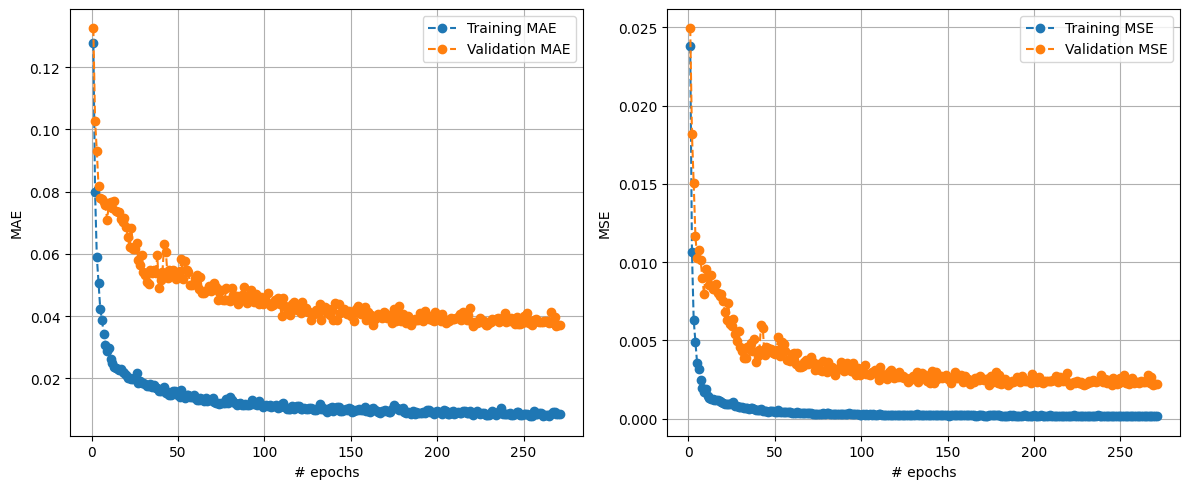

43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 1.7498e-04 - mean_absolute_error: 0.0088 - val_loss: 0.0022 - val_mean_absolute_error: 0.0371


In [80]:
lstm_model.fit(
      X_train_seq,
      y_train_seq,
      epochs=300,
      batch_size=72,
      validation_data=(X_val_seq, y_val_seq),
      callbacks=[
          PlotLearning(),
          EarlyStopping(monitor="val_loss", patience=50)
      ]
  )

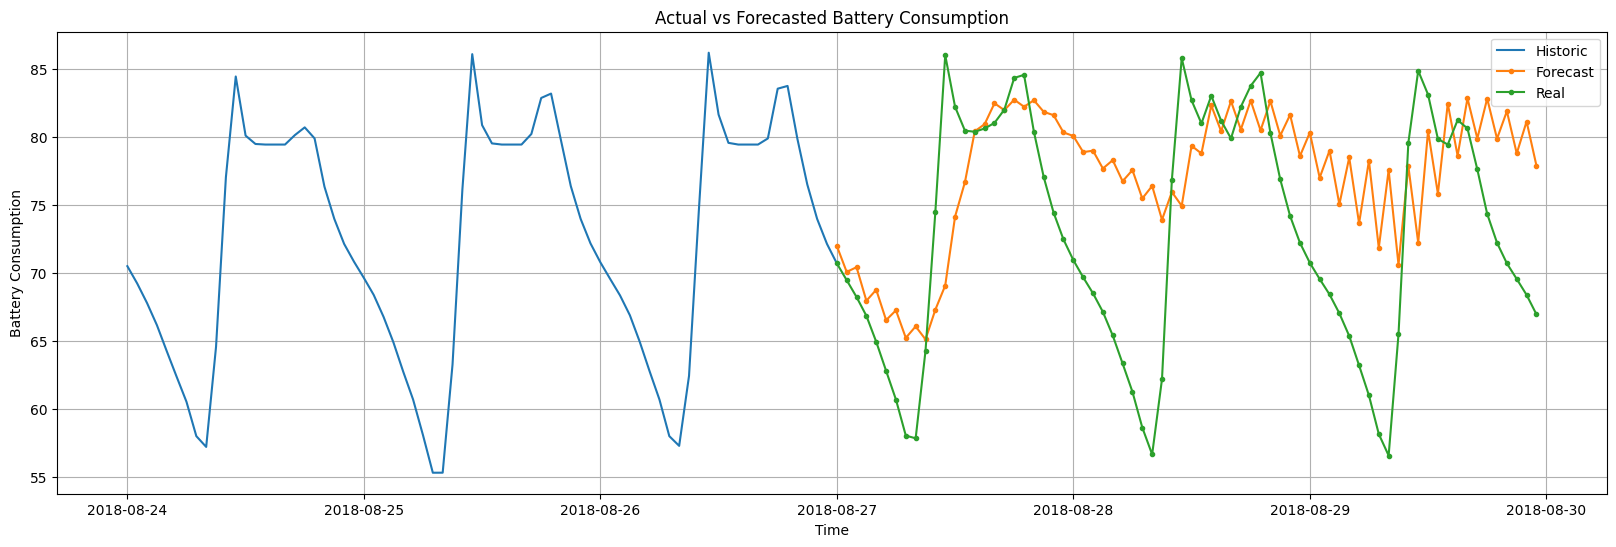

RMSE:  8.548699552402063
MSE:   73.08026403723923
MAE:   6.747338184780546


(                 fecha  temperature  pressure  battery  air_humidity  \
 0  2018-08-24 00:00:00      22.0525  986.0375  70.4875       60.2500   
 1  2018-08-24 01:00:00      21.3825  986.2075  69.2125       61.7975   
 2  2018-08-24 02:00:00      24.1225  985.9675  67.7700       61.9850   
 3  2018-08-24 03:00:00      25.5925  985.7325  66.1450       60.5050   
 4  2018-08-24 04:00:00      24.4625  985.6400  64.2275       61.4950   
 ..                 ...          ...       ...      ...           ...   
 68 2018-08-26 20:00:00      27.3125  984.4450  79.8525       61.2500   
 69 2018-08-26 21:00:00      24.8025  984.9600  76.5075       67.5050   
 70 2018-08-26 22:00:00      23.7150  985.4000  73.9700       69.4225   
 71 2018-08-26 23:00:00      22.4675  985.5450  72.1250       69.8875   
 72 2018-08-27 00:00:00      21.5750  985.6575  70.6925       71.6725   
 
     wind_speed  irradiancia  minutos_dia  hora  
 0       1.2050          0.0        807.0     0  
 1       1.2050       

In [81]:
forecast_battery_consumption(test=test_dataset, seq_length=seq_length,
                             forecast_steps=seq_length, future_steps=future_steps, model=lstm_model, scaler_x=scaler_x, scaler_y=scaler_y)

### Modelo doble LSTM

In [82]:
# Define model
lstm_double_model = Sequential()
lstm_double_model.add(LSTM(50, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
lstm_double_model.add(LSTM(50))
lstm_double_model.add(Dense(1, activation="sigmoid"))
lstm_double_model.compile(optimizer="adam", loss="mean_squared_error", metrics=["mean_absolute_error"])
lstm_double_model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 72, 50)              │          11,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,051 (125.20 KB)

 Trainable params: 32,051 (125.20 KB)

 Non-trainable params: 0 (0.00 B)

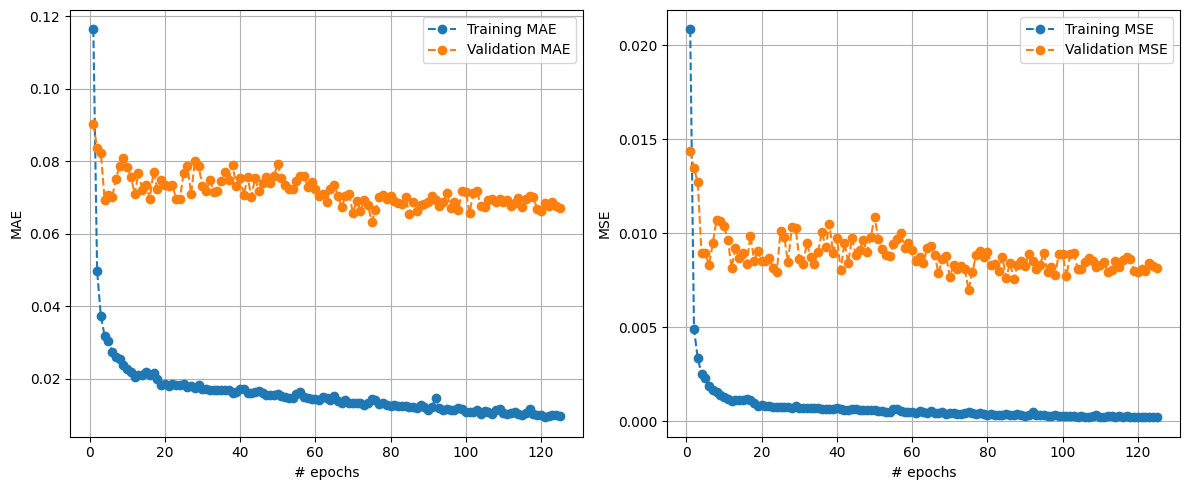

43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - loss: 1.9611e-04 - mean_absolute_error: 0.0097 - val_loss: 0.0082 - val_mean_absolute_error: 0.0671


In [83]:
lstm_double_model.fit(
      X_train_seq,
      y_train_seq,
      epochs=300,
      batch_size=72,
      validation_data=(X_val_seq, y_val_seq),
      callbacks=[
          PlotLearning(),
          EarlyStopping(monitor="val_loss", patience=50)
      ]
  )

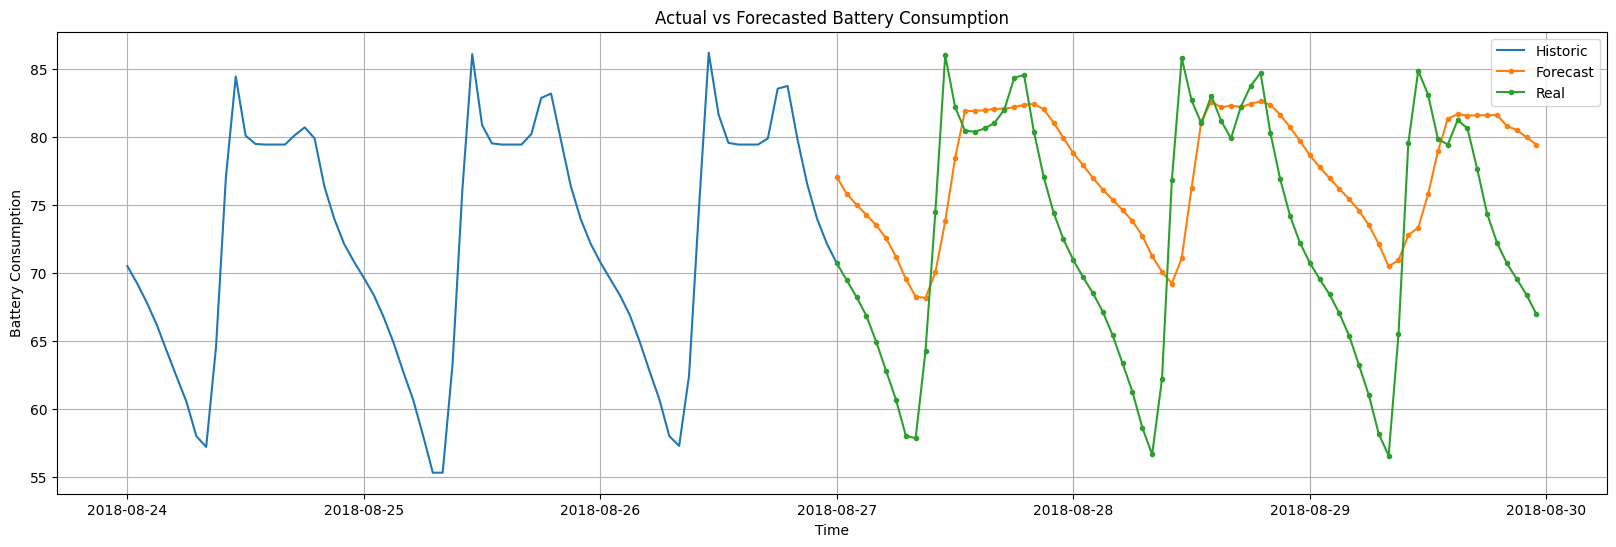

RMSE:  8.037190856311602
MSE:   64.59643686077882
MAE:   6.821357591417101


(                 fecha  temperature  pressure  battery  air_humidity  \
 0  2018-08-24 00:00:00      22.0525  986.0375  70.4875       60.2500   
 1  2018-08-24 01:00:00      21.3825  986.2075  69.2125       61.7975   
 2  2018-08-24 02:00:00      24.1225  985.9675  67.7700       61.9850   
 3  2018-08-24 03:00:00      25.5925  985.7325  66.1450       60.5050   
 4  2018-08-24 04:00:00      24.4625  985.6400  64.2275       61.4950   
 ..                 ...          ...       ...      ...           ...   
 68 2018-08-26 20:00:00      27.3125  984.4450  79.8525       61.2500   
 69 2018-08-26 21:00:00      24.8025  984.9600  76.5075       67.5050   
 70 2018-08-26 22:00:00      23.7150  985.4000  73.9700       69.4225   
 71 2018-08-26 23:00:00      22.4675  985.5450  72.1250       69.8875   
 72 2018-08-27 00:00:00      21.5750  985.6575  70.6925       71.6725   
 
     wind_speed  irradiancia  minutos_dia  hora  
 0       1.2050          0.0        807.0     0  
 1       1.2050       

In [84]:
forecast_battery_consumption(test=test_dataset, seq_length=seq_length, forecast_steps=seq_length,
                             future_steps=future_steps, model=lstm_double_model, scaler_x=scaler_x, scaler_y=scaler_y)

### Modelo LSTM libro Jason

In [85]:
n_nodes = 50
# define model
model = Sequential()
model.add(LSTM(n_nodes, activation='relu', input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
model.add(Dense(n_nodes, activation='relu'))
model.add(Dense(1, activation="sigmoid"))
model.compile(optimizer="adam", loss="mean_squared_error", metrics=["mean_absolute_error"])
model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                        │ (None, 50)                  │          11,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 50)                  │           2,550 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,401 (56.25 KB)

 Trainable params: 14,401 (56.25 KB)

 Non-trainable params: 0 (0.00 B)

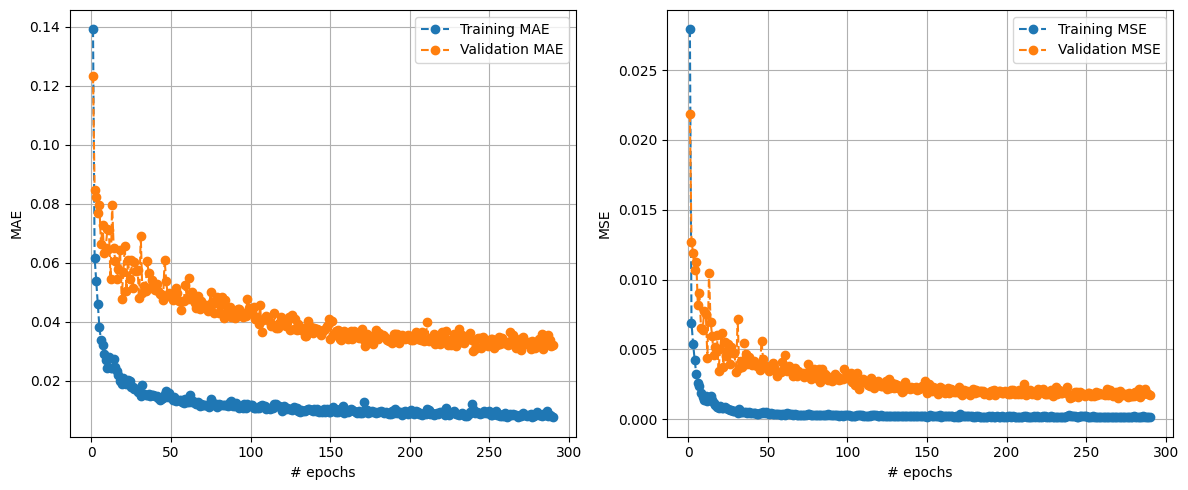

43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 1.2200e-04 - mean_absolute_error: 0.0075 - val_loss: 0.0018 - val_mean_absolute_error: 0.0322


In [86]:
model.fit(
      X_train_seq,
      y_train_seq,
      epochs=300,
      batch_size=72,
      validation_data=(X_val_seq, y_val_seq),
      callbacks=[
          PlotLearning(),
          EarlyStopping(monitor="val_loss", patience=50)
      ]
  )

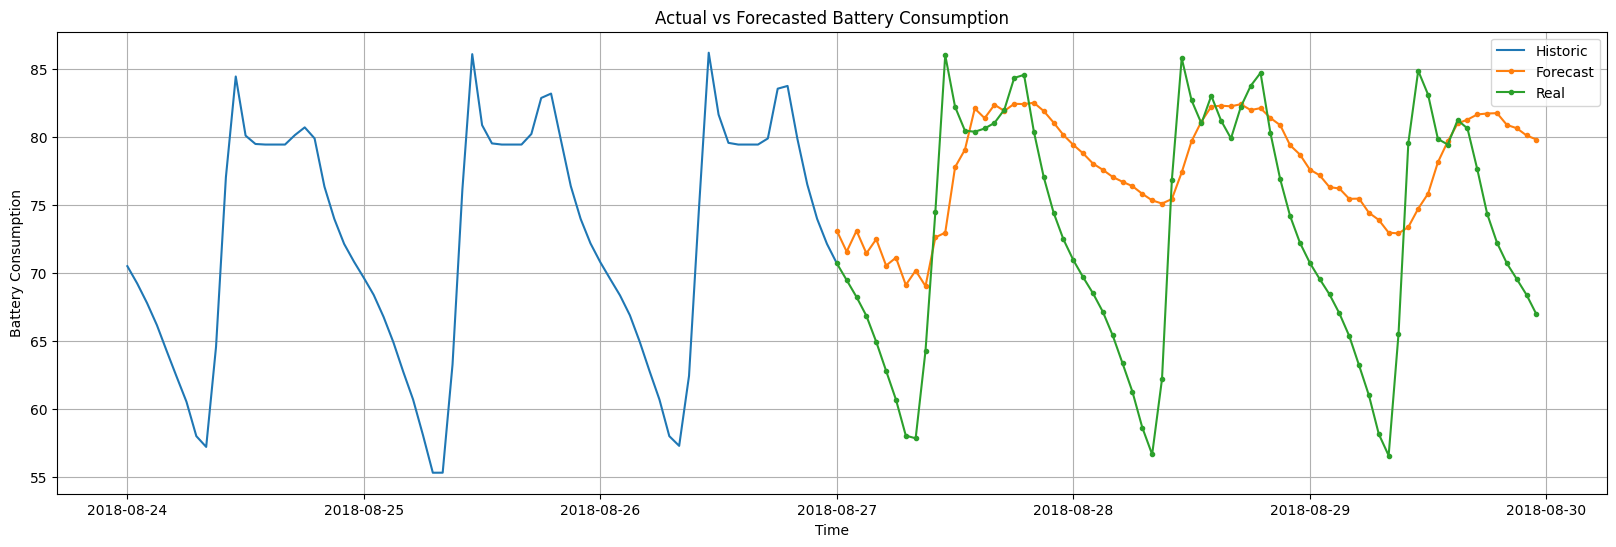

RMSE:  8.306579520638989
MSE:   68.99926333269906
MAE:   6.716498866611057


(                 fecha  temperature  pressure  battery  air_humidity  \
 0  2018-08-24 00:00:00      22.0525  986.0375  70.4875       60.2500   
 1  2018-08-24 01:00:00      21.3825  986.2075  69.2125       61.7975   
 2  2018-08-24 02:00:00      24.1225  985.9675  67.7700       61.9850   
 3  2018-08-24 03:00:00      25.5925  985.7325  66.1450       60.5050   
 4  2018-08-24 04:00:00      24.4625  985.6400  64.2275       61.4950   
 ..                 ...          ...       ...      ...           ...   
 68 2018-08-26 20:00:00      27.3125  984.4450  79.8525       61.2500   
 69 2018-08-26 21:00:00      24.8025  984.9600  76.5075       67.5050   
 70 2018-08-26 22:00:00      23.7150  985.4000  73.9700       69.4225   
 71 2018-08-26 23:00:00      22.4675  985.5450  72.1250       69.8875   
 72 2018-08-27 00:00:00      21.5750  985.6575  70.6925       71.6725   
 
     wind_speed  irradiancia  minutos_dia  hora  
 0       1.2050          0.0        807.0     0  
 1       1.2050       

In [87]:
forecast_battery_consumption(test=test_dataset, seq_length=seq_length, forecast_steps=seq_length,
                             future_steps=future_steps, model=model, scaler_x=scaler_x, scaler_y=scaler_y)

### Modelo Sofisticado

In [88]:
from keras.layers import Dropout

# Crear el modelo
model = Sequential()
# Capa LSTM 1 (con 50 unidades)
model.add(LSTM(50, return_sequences=True, input_shape=(n_steps, n_features)))
# Dropout para regularización
model.add(Dropout(0.2))
# Capa LSTM 2 (con 50 unidades)
model.add(LSTM(50))
# Dropout para regularización
model.add(Dropout(0.2))
# Capa densa 1 (con 64 neuronas)
model.add(Dense(64, activation='relu'))
# Capa densa 2 (con 32 neuronas)
model.add(Dense(32, activation='relu'))
# Capa de salida (con 1 neurona para la predicción final)
model.add(Dense(1))
model.compile(optimizer="adam", loss="mean_squared_error", metrics=["mean_absolute_error"])
model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 72, 50)              │          11,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 72, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           3,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 37,377 (146.00 KB)

 Trainable params: 37,377 (146.00 KB)

 Non-trainable params: 0 (0.00 B)

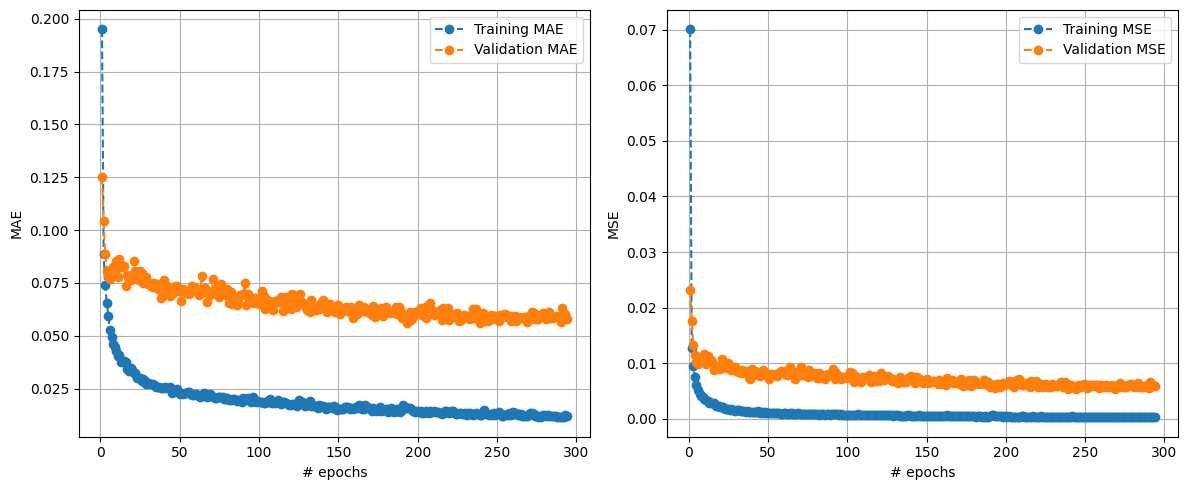

43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 137ms/step - loss: 3.1361e-04 - mean_absolute_error: 0.0125 - val_loss: 0.0059 - val_mean_absolute_error: 0.0581


In [89]:
model.fit(
      X_train_seq,
      y_train_seq,
      epochs=300,
      batch_size=72,
      validation_data=(X_val_seq, y_val_seq),
      callbacks=[
          PlotLearning(),
          EarlyStopping(monitor="val_loss", patience=50)
      ]
  )

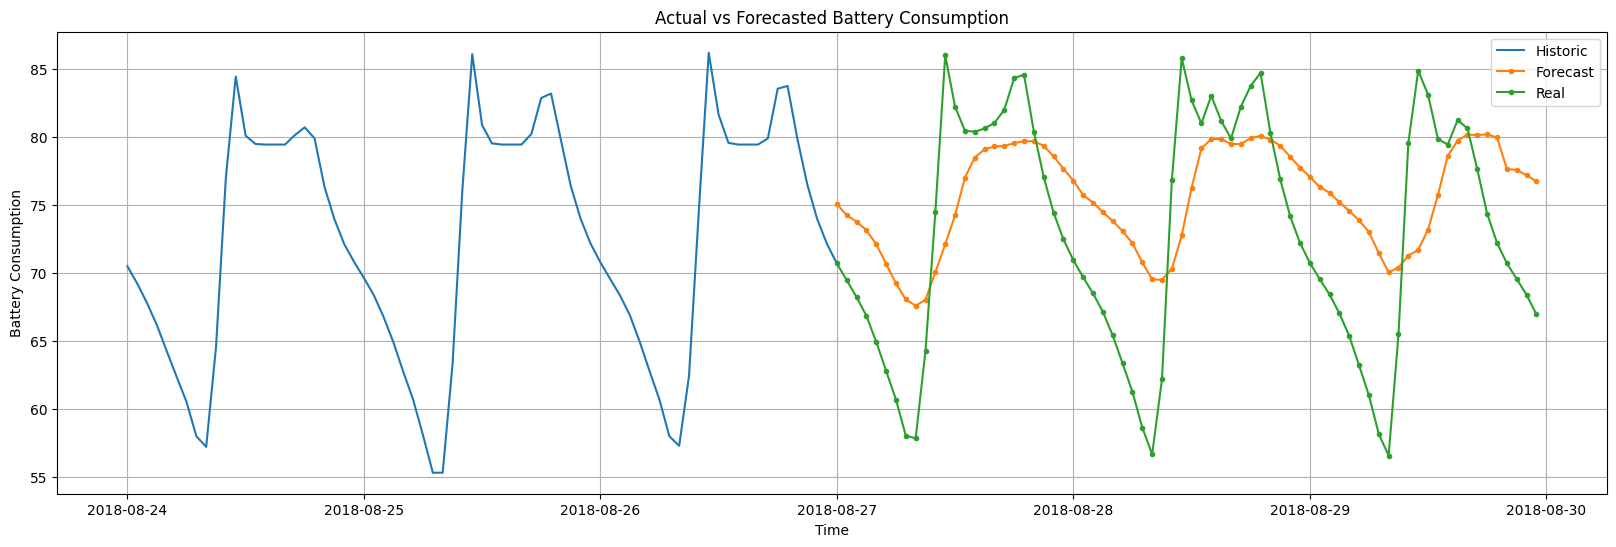

RMSE:  7.253682028331691
MSE:   52.61590296814216
MAE:   6.286121847364638


(                 fecha  temperature  pressure  battery  air_humidity  \
 0  2018-08-24 00:00:00      22.0525  986.0375  70.4875       60.2500   
 1  2018-08-24 01:00:00      21.3825  986.2075  69.2125       61.7975   
 2  2018-08-24 02:00:00      24.1225  985.9675  67.7700       61.9850   
 3  2018-08-24 03:00:00      25.5925  985.7325  66.1450       60.5050   
 4  2018-08-24 04:00:00      24.4625  985.6400  64.2275       61.4950   
 ..                 ...          ...       ...      ...           ...   
 68 2018-08-26 20:00:00      27.3125  984.4450  79.8525       61.2500   
 69 2018-08-26 21:00:00      24.8025  984.9600  76.5075       67.5050   
 70 2018-08-26 22:00:00      23.7150  985.4000  73.9700       69.4225   
 71 2018-08-26 23:00:00      22.4675  985.5450  72.1250       69.8875   
 72 2018-08-27 00:00:00      21.5750  985.6575  70.6925       71.6725   
 
     wind_speed  irradiancia  minutos_dia  hora  
 0       1.2050          0.0        807.0     0  
 1       1.2050       

In [90]:
forecast_battery_consumption(test=test_dataset, seq_length=seq_length, forecast_steps=seq_length,
                             future_steps=future_steps, model=model, scaler_x=scaler_x, scaler_y=scaler_y)

### Modelo GRU

In [ ]:
# Define model
gru_model = Sequential()
gru_model.add(GRU(units=50, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
gru_model.add(Dense(1, activation='sigmoid'))
gru_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])
gru_model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 50)                  │           9,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,051 (35.36 KB)

 Trainable params: 9,051 (35.36 KB)

 Non-trainable params: 0 (0.00 B)

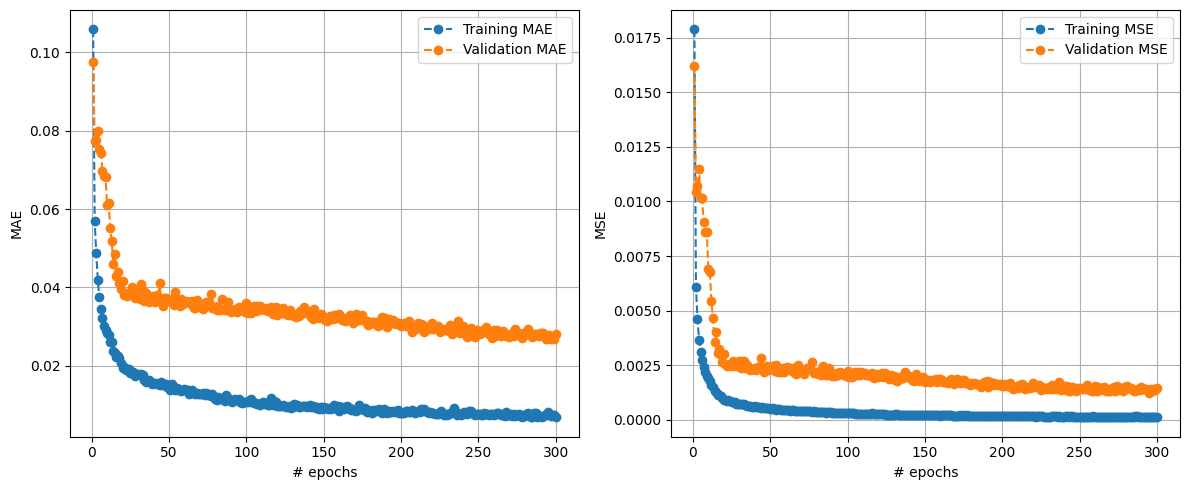

43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 1.0310e-04 - mean_absolute_error: 0.0068 - val_loss: 0.0015 - val_mean_absolute_error: 0.0282


In [ ]:
gru_model.fit(X_train_seq,
              y_train_seq,
              epochs=300,
              batch_size=72,
              validation_data=(X_val_seq, y_val_seq),
              callbacks=[
              PlotLearning(),
              EarlyStopping(monitor='val_loss', patience=50)])

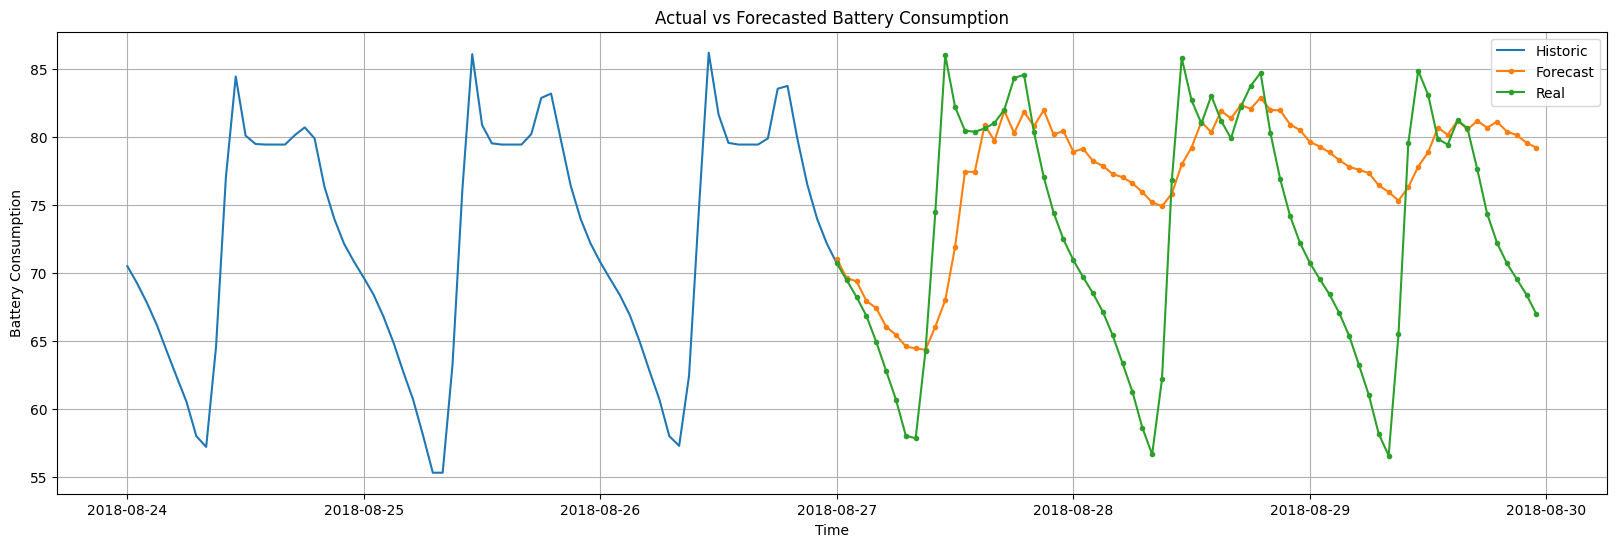

RMSE:  8.586815090744478
MSE:   73.73339340263709
MAE:   6.624587482876247


(                 fecha  temperature  pressure  battery  air_humidity  \
 0  2018-08-24 00:00:00      22.0525  986.0375  70.4875       60.2500   
 1  2018-08-24 01:00:00      21.3825  986.2075  69.2125       61.7975   
 2  2018-08-24 02:00:00      24.1225  985.9675  67.7700       61.9850   
 3  2018-08-24 03:00:00      25.5925  985.7325  66.1450       60.5050   
 4  2018-08-24 04:00:00      24.4625  985.6400  64.2275       61.4950   
 ..                 ...          ...       ...      ...           ...   
 68 2018-08-26 20:00:00      27.3125  984.4450  79.8525       61.2500   
 69 2018-08-26 21:00:00      24.8025  984.9600  76.5075       67.5050   
 70 2018-08-26 22:00:00      23.7150  985.4000  73.9700       69.4225   
 71 2018-08-26 23:00:00      22.4675  985.5450  72.1250       69.8875   
 72 2018-08-27 00:00:00      21.5750  985.6575  70.6925       71.6725   
 
     wind_speed  irradiancia  minutos_dia  hora  
 0       1.2050          0.0        807.0     0  
 1       1.2050       

In [ ]:
forecast_battery_consumption(test=test_dataset, seq_length=seq_length, forecast_steps=seq_length,
                             future_steps=future_steps, model=gru_model, scaler_x=scaler_x, scaler_y=scaler_y)

### Modelo doble GRU

In [ ]:
# Define model
gru_double_model = Sequential()
gru_double_model.add(GRU(units=50, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
gru_double_model.add(GRU(units=50))
gru_double_model.add(Dense(1, activation='sigmoid'))
gru_double_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])
gru_double_model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                          │ (None, 72, 50)              │           9,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_2 (GRU)                          │ (None, 50)                  │          15,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,351 (95.12 KB)

 Trainable params: 24,351 (95.12 KB)

 Non-trainable params: 0 (0.00 B)

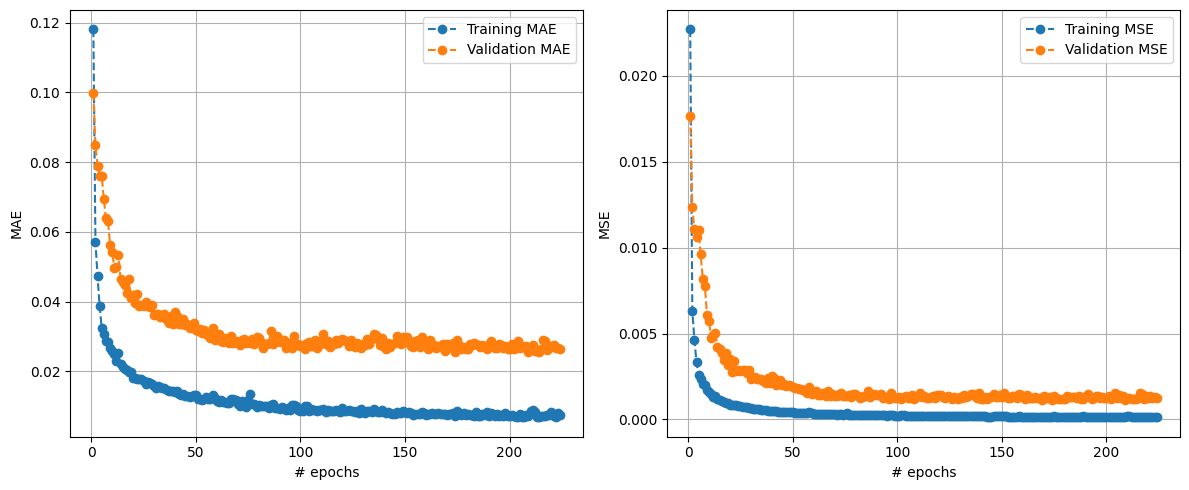

43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 1.2018e-04 - mean_absolute_error: 0.0076 - val_loss: 0.0013 - val_mean_absolute_error: 0.0264


In [ ]:
gru_double_model.fit(X_train_seq,
                    y_train_seq,
                    epochs=300,
                    batch_size=72,
                    validation_data=(X_val_seq, y_val_seq),
                    callbacks=[
                    PlotLearning(),
                    EarlyStopping(monitor='val_loss', patience=50)])

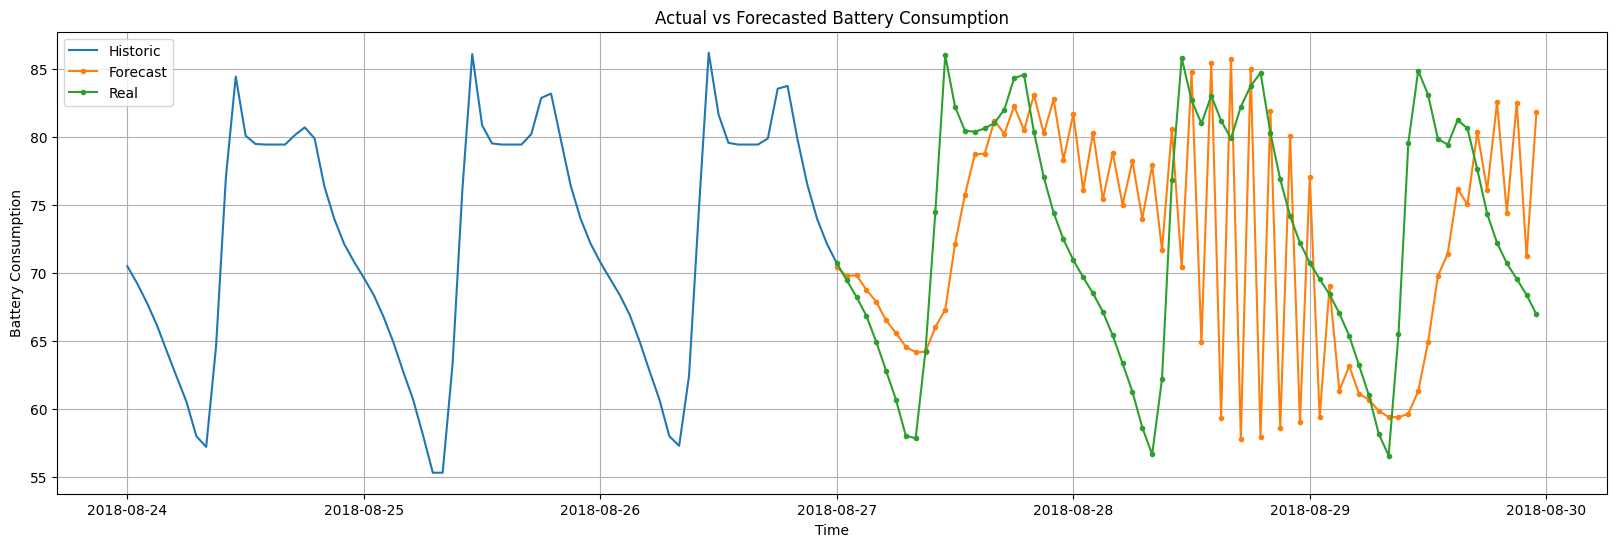

RMSE:  10.377917636152622
MSE:   107.70117446276764
MAE:   7.84392640431722


(                 fecha  temperature  pressure  battery  air_humidity  \
 0  2018-08-24 00:00:00      22.0525  986.0375  70.4875       60.2500   
 1  2018-08-24 01:00:00      21.3825  986.2075  69.2125       61.7975   
 2  2018-08-24 02:00:00      24.1225  985.9675  67.7700       61.9850   
 3  2018-08-24 03:00:00      25.5925  985.7325  66.1450       60.5050   
 4  2018-08-24 04:00:00      24.4625  985.6400  64.2275       61.4950   
 ..                 ...          ...       ...      ...           ...   
 68 2018-08-26 20:00:00      27.3125  984.4450  79.8525       61.2500   
 69 2018-08-26 21:00:00      24.8025  984.9600  76.5075       67.5050   
 70 2018-08-26 22:00:00      23.7150  985.4000  73.9700       69.4225   
 71 2018-08-26 23:00:00      22.4675  985.5450  72.1250       69.8875   
 72 2018-08-27 00:00:00      21.5750  985.6575  70.6925       71.6725   
 
     wind_speed  irradiancia  minutos_dia  hora  
 0       1.2050          0.0        807.0     0  
 1       1.2050       

In [ ]:
forecast_battery_consumption(test=test_dataset, seq_length=seq_length, forecast_steps=seq_length,
                             future_steps=future_steps, model=gru_double_model, scaler_x=scaler_x, scaler_y=scaler_y)

In [ ]:
#compare_model_performance(test=test_dataset, seq_length=seq_length, future_steps=seq_length, models=[('gru_model', gru_model), ('gru_double_model',
#                         gru_double_model)], scaler_x=scaler_x, scaler_y=scaler_y)

### Modelo GRU libro Jason

In [ ]:
# Define model
gru_modelj = Sequential()
gru_modelj.add(GRU(units=50, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
gru_modelj.add(Dense(n_nodes, activation='relu'))
gru_modelj.add(Dense(1, activation='sigmoid'))
gru_modelj.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])
gru_modelj.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru_3 (GRU)                          │ (None, 50)                  │           9,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 50)                  │           2,550 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,601 (45.32 KB)

 Trainable params: 11,601 (45.32 KB)

 Non-trainable params: 0 (0.00 B)

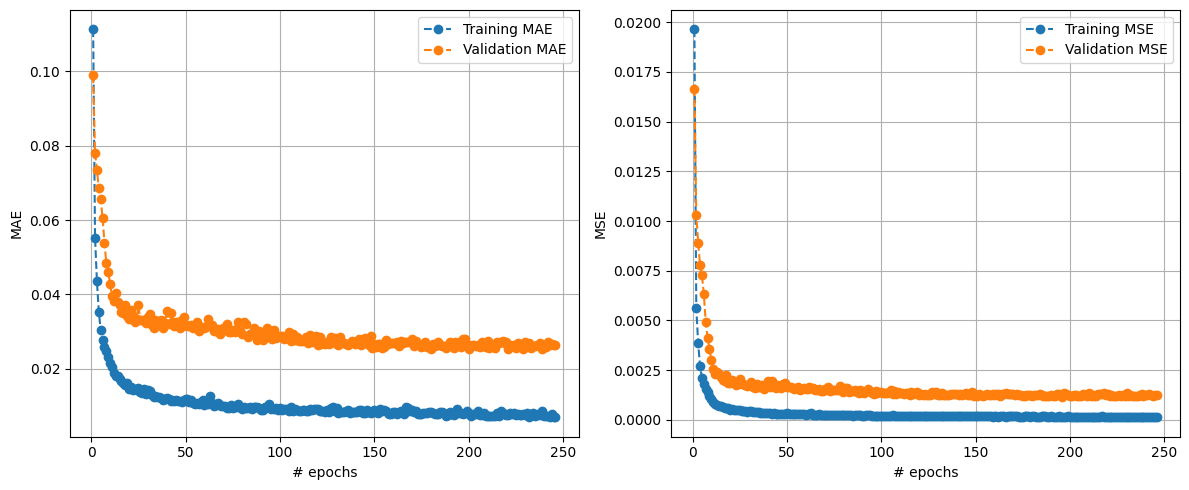

43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 1.2584e-04 - mean_absolute_error: 0.0072 - val_loss: 0.0012 - val_mean_absolute_error: 0.0264


In [ ]:
gru_modelj.fit(X_train_seq,
                    y_train_seq,
                    epochs=300,
                    batch_size=72,
                    validation_data=(X_val_seq, y_val_seq),
                    callbacks=[
                    PlotLearning(),
                    EarlyStopping(monitor='val_loss', patience=50)])

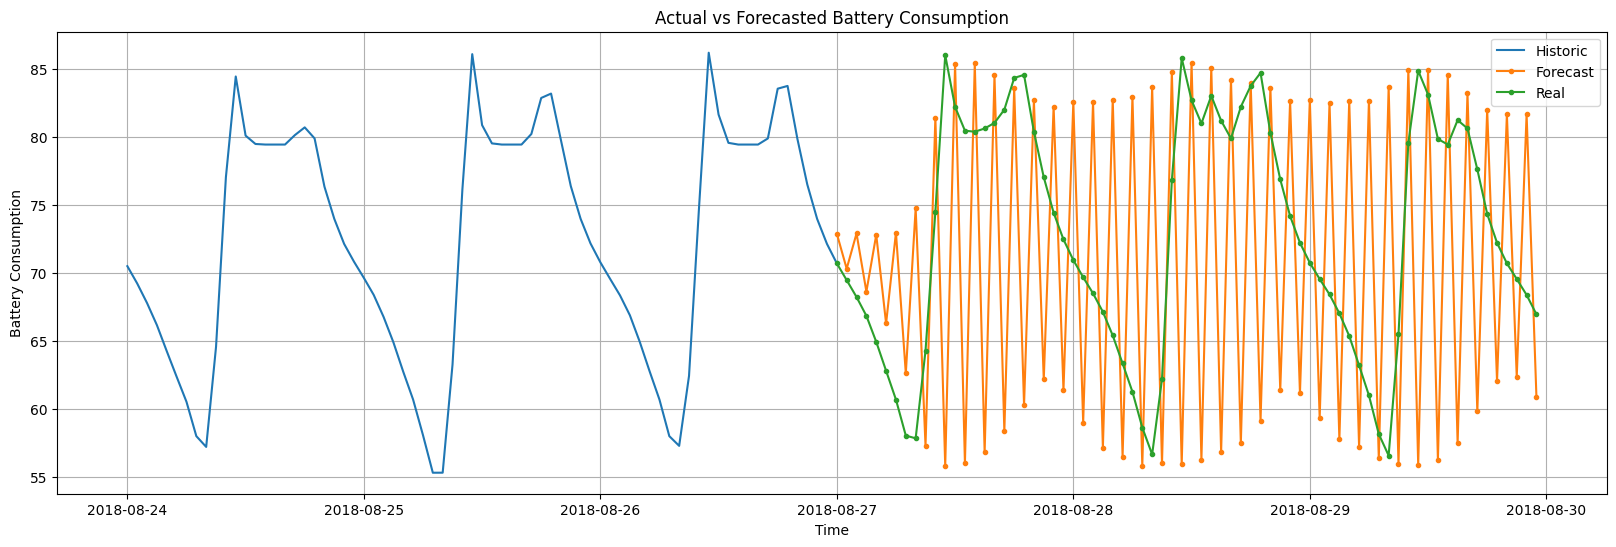

RMSE:  14.658953582782482
MSE:   214.88492014217138
MAE:   11.814201566908094


(                 fecha  temperature  pressure  battery  air_humidity  \
 0  2018-08-24 00:00:00      22.0525  986.0375  70.4875       60.2500   
 1  2018-08-24 01:00:00      21.3825  986.2075  69.2125       61.7975   
 2  2018-08-24 02:00:00      24.1225  985.9675  67.7700       61.9850   
 3  2018-08-24 03:00:00      25.5925  985.7325  66.1450       60.5050   
 4  2018-08-24 04:00:00      24.4625  985.6400  64.2275       61.4950   
 ..                 ...          ...       ...      ...           ...   
 68 2018-08-26 20:00:00      27.3125  984.4450  79.8525       61.2500   
 69 2018-08-26 21:00:00      24.8025  984.9600  76.5075       67.5050   
 70 2018-08-26 22:00:00      23.7150  985.4000  73.9700       69.4225   
 71 2018-08-26 23:00:00      22.4675  985.5450  72.1250       69.8875   
 72 2018-08-27 00:00:00      21.5750  985.6575  70.6925       71.6725   
 
     wind_speed  irradiancia  minutos_dia  hora  
 0       1.2050          0.0        807.0     0  
 1       1.2050       

In [ ]:
forecast_battery_consumption(test=test_dataset, seq_length=seq_length, forecast_steps=seq_length,
                             future_steps=future_steps, model=gru_modelj, scaler_x=scaler_x, scaler_y=scaler_y)

### Modelo GRU Sofisticado

In [92]:
# Crear el modelo
gru_models = Sequential()
# Capa GRU 1 (con 50 unidades)
gru_models.add(GRU(50, return_sequences=True, input_shape=(n_steps, n_features)))
# Dropout para regularización
gru_models.add(Dropout(0.2))
# Capa GRU 2 (con 50 unidades)
gru_models.add(GRU(50))
# Dropout para regularización
gru_models.add(Dropout(0.2))
# Capa densa 1 (con 64 neuronas)
gru_models.add(Dense(64, activation='relu'))
# Capa densa 2 (con 32 neuronas)
gru_models.add(Dense(32, activation='relu'))
# Capa de salida (con 1 neurona para la predicción final)
gru_models.add(Dense(1))
gru_models.compile(optimizer="adam", loss="mean_squared_error", metrics=["mean_absolute_error"])
gru_models.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 72, 50)              │           9,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 72, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 50)                  │          15,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │           3,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,677 (115.93 KB)

 Trainable params: 29,677 (115.93 KB)

 Non-trainable params: 0 (0.00 B)

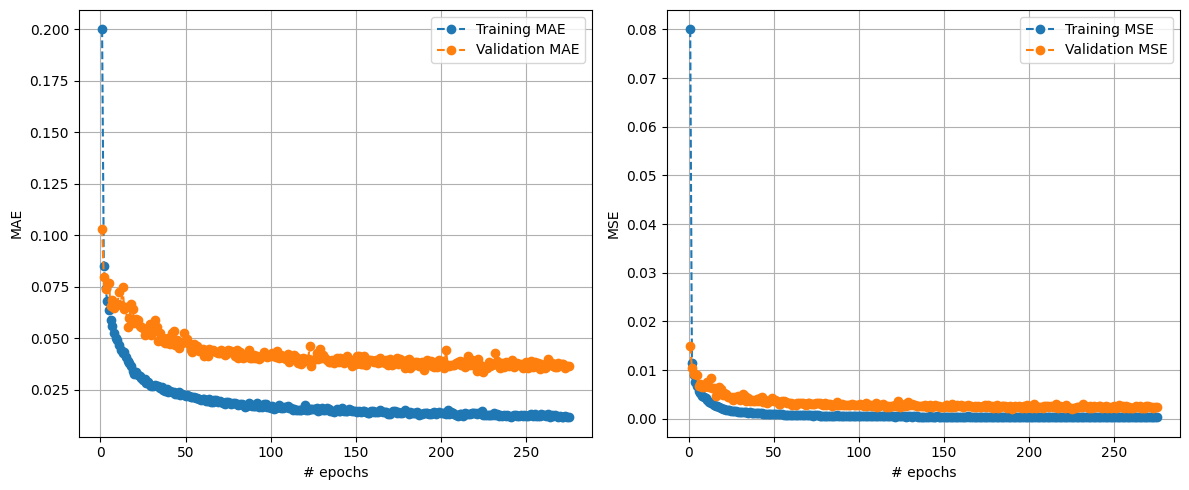

43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 2.6549e-04 - mean_absolute_error: 0.0117 - val_loss: 0.0023 - val_mean_absolute_error: 0.0367


In [93]:
gru_models.fit(X_train_seq,
                    y_train_seq,
                    epochs=300,
                    batch_size=72,
                    validation_data=(X_val_seq, y_val_seq),
                    callbacks=[
                    PlotLearning(),
                    EarlyStopping(monitor='val_loss', patience=50)])

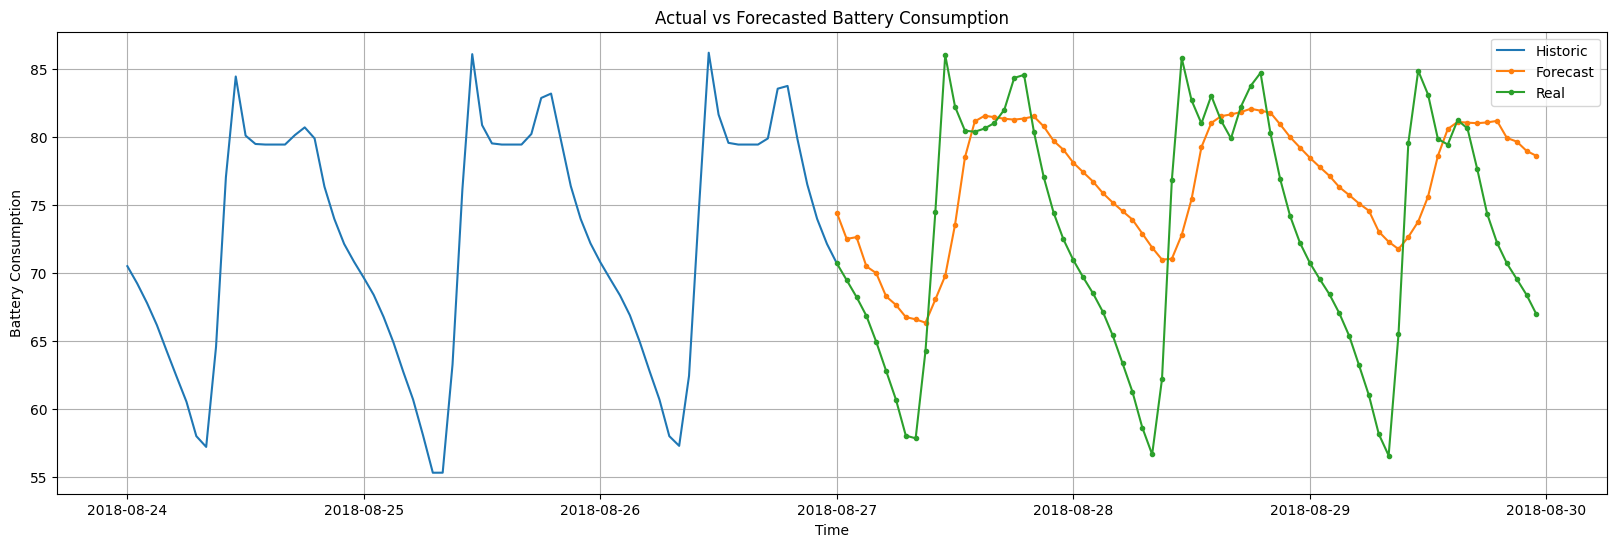

RMSE:  7.797052822512054
MSE:   60.79403271704319
MAE:   6.472497821384007


(                 fecha  temperature  pressure  battery  air_humidity  \
 0  2018-08-24 00:00:00      22.0525  986.0375  70.4875       60.2500   
 1  2018-08-24 01:00:00      21.3825  986.2075  69.2125       61.7975   
 2  2018-08-24 02:00:00      24.1225  985.9675  67.7700       61.9850   
 3  2018-08-24 03:00:00      25.5925  985.7325  66.1450       60.5050   
 4  2018-08-24 04:00:00      24.4625  985.6400  64.2275       61.4950   
 ..                 ...          ...       ...      ...           ...   
 68 2018-08-26 20:00:00      27.3125  984.4450  79.8525       61.2500   
 69 2018-08-26 21:00:00      24.8025  984.9600  76.5075       67.5050   
 70 2018-08-26 22:00:00      23.7150  985.4000  73.9700       69.4225   
 71 2018-08-26 23:00:00      22.4675  985.5450  72.1250       69.8875   
 72 2018-08-27 00:00:00      21.5750  985.6575  70.6925       71.6725   
 
     wind_speed  irradiancia  minutos_dia  hora  
 0       1.2050          0.0        807.0     0  
 1       1.2050       

In [94]:
forecast_battery_consumption(test=test_dataset, seq_length=seq_length, forecast_steps=seq_length,
                             future_steps=future_steps, model=gru_models, scaler_x=scaler_x, scaler_y=scaler_y)